# Statistical Modeling of NBA Match Outcomes
## Analytical Study: Random Forest Ensemble Methods
**Author: Analytics Lead**

This research focuses on leveraging **Random Forest Classifiers** to determine the probability of home-team victories. By aggregating multiple decision trees, we aim to reduce variance and capture non-linear relationships within the NBA statistics dataset.

### 1. Environment Preparation


In [1]:
import subprocess
import sys

packages = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn']

for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print('All packages installed successfully!')

All packages installed successfully!


### 1.1 Data Ingestion via Kaggle API


In [2]:
import os
import subprocess
import sys

if not os.path.exists('games.csv'):
    print('games.csv not found. Downloading dataset...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'kagglehub'])
    import kagglehub
    path = kagglehub.dataset_download('nathanlauga/nba-games')
    print('Dataset downloaded to:', path)
    # Copy games.csv to current directory
    import shutil
    for root, dirs, files in os.walk(path):
        for file in files:
            if file == 'games.csv':
                shutil.copy2(os.path.join(root, file), 'games.csv')
                print('games.csv copied to current directory!')
                break
else:
    print('games.csv already exists. Skipping download.')

games.csv already exists. Skipping download.


## 2. Dependency Inclusion


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 3. Exploratory Data Analysis (EDA)


In [4]:
# Load the dataset
# Download from: https://www.kaggle.com/datasets/nathanlauga/nba-games
# Place games.csv in the same folder as this notebook
df = pd.read_csv('games.csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()

Shape: (26651, 21)

Columns: ['GAME_DATE_EST', 'GAME_ID', 'GAME_STATUS_TEXT', 'HOME_TEAM_ID', 'VISITOR_TEAM_ID', 'SEASON', 'TEAM_ID_home', 'PTS_home', 'FG_PCT_home', 'FT_PCT_home', 'FG3_PCT_home', 'AST_home', 'REB_home', 'TEAM_ID_away', 'PTS_away', 'FG_PCT_away', 'FT_PCT_away', 'FG3_PCT_away', 'AST_away', 'REB_away', 'HOME_TEAM_WINS']


,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-12-22,22200477,Final,1610612740,1610612759,2022,1610612740,126.0,0.484,0.926,...,25.0,46.0,1610612759,117.0,0.478,0.815,0.321,23.0,44.0,1
1,2022-12-22,22200478,Final,1610612762,1610612764,2022,1610612762,120.0,0.488,0.952,...,16.0,40.0,1610612764,112.0,0.561,0.765,0.333,20.0,37.0,1
2,2022-12-21,22200466,Final,1610612739,1610612749,2022,1610612739,114.0,0.482,0.786,...,22.0,37.0,1610612749,106.0,0.470,0.682,0.433,20.0,46.0,1
3,2022-12-21,22200467,Final,1610612755,1610612765,2022,1610612755,113.0,0.441,0.909,...,27.0,49.0,1610612765,93.0,0.392,0.735,0.261,15.0,46.0,1
4,2022-12-21,22200468,Final,1610612737,1610612741,2022,1610612737,108.0,0.429,1.000,...,22.0,47.0,1610612741,110.0,0.500,0.773,0.292,20.0,47.0,0


In [5]:
# Basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26651 entries, 0 to 26650
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   GAME_DATE_EST     26651 non-null  str    
 1   GAME_ID           26651 non-null  int64  
 2   GAME_STATUS_TEXT  26651 non-null  str    
 3   HOME_TEAM_ID      26651 non-null  int64  
 4   VISITOR_TEAM_ID   26651 non-null  int64  
 5   SEASON            26651 non-null  int64  
 6   TEAM_ID_home      26651 non-null  int64  
 7   PTS_home          26552 non-null  float64
 8   FG_PCT_home       26552 non-null  float64
 9   FT_PCT_home       26552 non-null  float64
 10  FG3_PCT_home      26552 non-null  float64
 11  AST_home          26552 non-null  float64
 12  REB_home          26552 non-null  float64
 13  TEAM_ID_away      26651 non-null  int64  
 14  PTS_away          26552 non-null  float64
 15  FG_PCT_away       26552 non-null  float64
 16  FT_PCT_away       26552 non-null  float64
 17  FG3_

In [6]:
# Check missing values
print('Missing values per column:')
print(df.isnull().sum())
print('\nBasic statistics:')
df.describe()

Missing values per column:
GAME_DATE_EST        0
GAME_ID              0
GAME_STATUS_TEXT     0
HOME_TEAM_ID         0
VISITOR_TEAM_ID      0
SEASON               0
TEAM_ID_home         0
PTS_home            99
FG_PCT_home         99
FT_PCT_home         99
FG3_PCT_home        99
AST_home            99
REB_home            99
TEAM_ID_away         0
PTS_away            99
FG_PCT_away         99
FT_PCT_away         99
FG3_PCT_away        99
AST_away            99
REB_away            99
HOME_TEAM_WINS       0
dtype: int64

Basic statistics:


,GAME_ID,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,FG3_PCT_home,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
count,2.665100e+04,2.665100e+04,2.665100e+04,26651.000000,2.665100e+04,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,2.665100e+04,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26651.000000
mean,2.175487e+07,1.610613e+09,1.610613e+09,2012.113879,1.610613e+09,103.455898,0.460735,0.760377,0.356023,22.823441,43.374284,1.610613e+09,100.639876,0.449732,0.758816,0.349489,21.496271,42.113249,0.587032
std,5.570189e+06,8.638670e+00,8.659299e+00,5.587031,8.638670e+00,13.283370,0.056676,0.100677,0.111164,5.193308,6.625769,8.659299e+00,13.435868,0.055551,0.103429,0.109441,5.160596,6.533039,0.492376
min,1.030000e+07,1.610613e+09,1.610613e+09,2003.000000,1.610613e+09,36.000000,0.250000,0.143000,0.000000,6.000000,15.000000,1.610613e+09,33.000000,0.244000,0.143000,0.000000,4.000000,19.000000,0.000000
25%,2.070001e+07,1.610613e+09,1.610613e+09,2007.000000,1.610613e+09,94.000000,0.422000,0.697000,0.286000,19.000000,39.000000,1.610613e+09,91.000000,0.412000,0.692000,0.278000,18.000000,38.000000,0.000000
50%,2.120076e+07,1.610613e+09,1.610613e+09,2012.000000,1.610613e+09,103.000000,0.460000,0.765000,0.357000,23.000000,43.000000,1.610613e+09,100.000000,0.449000,0.765000,0.350000,21.000000,42.000000,1.000000
75%,2.180005e+07,1.610613e+09,1.610613e+09,2017.000000,1.610613e+09,112.000000,0.500000,0.833000,0.429000,26.000000,48.000000,1.610613e+09,110.000000,0.487000,0.833000,0.419000,25.000000,46.000000,1.000000
max,5.210021e+07,1.610613e+09,1.610613e+09,2022.000000,1.610613e+09,168.000000,0.684000,1.000000,1.000000,50.000000,72.000000,1.610613e+09,168.000000,0.687000,1.000000,1.000000,46.000000,81.000000,1.000000


## 3. Data Preprocessing

In [7]:
# Select relevant features
features = [
    'FG_PCT_home', 'FT_PCT_home', 'FG3_PCT_home', 'AST_home', 'REB_home',
    'FG_PCT_away', 'FT_PCT_away', 'FG3_PCT_away', 'AST_away', 'REB_away'
]

# Target: HOME_TEAM_WINS (1 = home wins, 0 = away wins)
target = 'HOME_TEAM_WINS'

# Drop rows with nulls in these columns
df_clean = df[features + [target]].dropna()

print(f'Clean dataset shape: {df_clean.shape}')
print(f'\nTarget distribution:')
print(df_clean[target].value_counts())
print(f'\nHome Win Rate: {df_clean[target].mean()*100:.2f}%')

Clean dataset shape: (26552, 11)

Target distribution:
HOME_TEAM_WINS
1    15645
0    10907
Name: count, dtype: int64

Home Win Rate: 58.92%


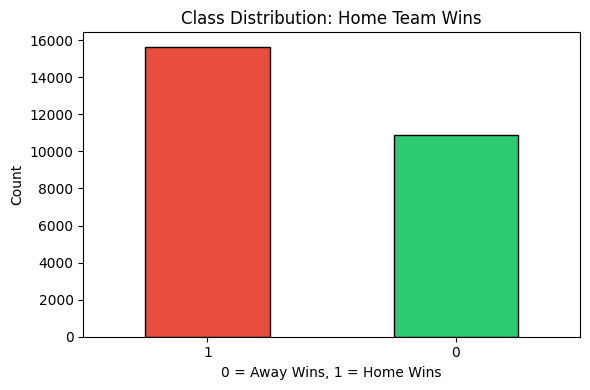

In [8]:
# Visualize class distribution
plt.figure(figsize=(6,4))
df_clean[target].value_counts().plot(kind='bar', color=['#e74c3c','#2ecc71'], edgecolor='black')
plt.title('Class Distribution: Home Team Wins')
plt.xlabel('0 = Away Wins, 1 = Home Wins')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('rf_class_distribution.png', dpi=150)
plt.show()

In [9]:
# Split features and target
X = df_clean[features]
y = df_clean[target]

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

Training samples: 21241
Testing samples:  5311


## 5. Implementation: Random Forest Classifier Ensemble

In [10]:
# Train baseline model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
print('Random Forest model trained!')

Random Forest model trained!


In [11]:
# Hyperparameter tuning with GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                           param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print('Best parameters:', grid_search.best_params_)
print('Best CV accuracy:', round(grid_search.best_score_ * 100, 2), '%')

# Use best model
best_rf = grid_search.best_estimator_

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV accuracy: 83.86 %


## 6. Performance Evaluation

In [12]:
# Predictions
y_pred = best_rf.predict(X_test_scaled)
y_prob = best_rf.predict_proba(X_test_scaled)[:, 1]

# Metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print('=' * 40)
print('   RANDOM FOREST  -  TEST RESULTS')
print('=' * 40)
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {prec*100:.2f}%')
print(f'  Recall    : {rec*100:.2f}%')
print(f'  F1-Score  : {f1*100:.2f}%')
print(f'  ROC-AUC   : {auc:.4f}')
print('=' * 40)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Away Wins','Home Wins']))

   RANDOM FOREST  -  TEST RESULTS
  Accuracy  : 83.62%
  Precision : 85.66%
  Recall    : 86.71%
  F1-Score  : 86.18%
  ROC-AUC   : 0.9174

Classification Report:
              precision    recall  f1-score   support

   Away Wins       0.81      0.79      0.80      2182
   Home Wins       0.86      0.87      0.86      3129

    accuracy                           0.84      5311
   macro avg       0.83      0.83      0.83      5311
weighted avg       0.84      0.84      0.84      5311



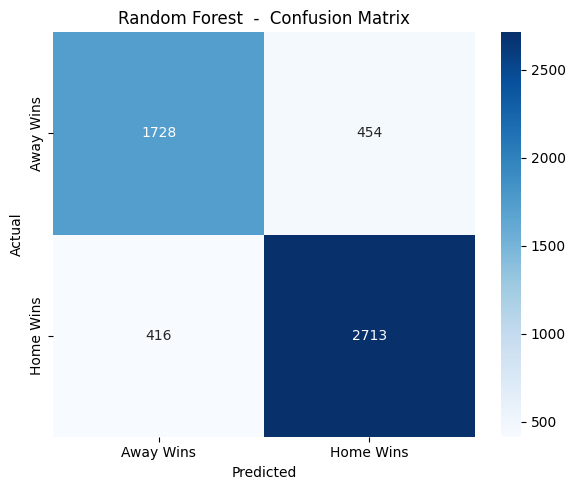

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Away Wins','Home Wins'],
            yticklabels=['Away Wins','Home Wins'])
plt.title('Random Forest  -  Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150)
plt.show()

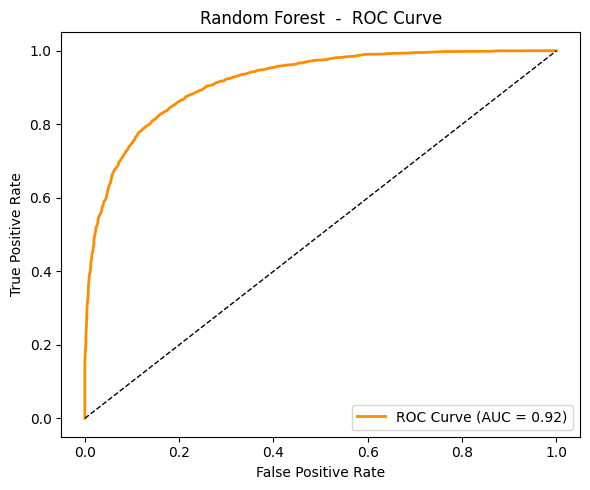

In [14]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest  -  ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('rf_roc_curve.png', dpi=150)
plt.show()

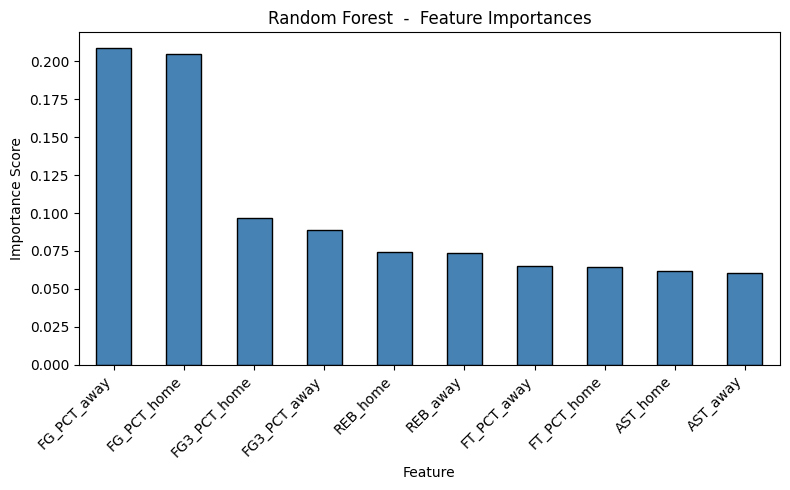

Top Features:
FG_PCT_away     0.208665
FG_PCT_home     0.204699
FG3_PCT_home    0.096974
FG3_PCT_away    0.088896
REB_home        0.074516
REB_away        0.073972
FT_PCT_away     0.064884
FT_PCT_home     0.064701
AST_home        0.062016
AST_away        0.060677
dtype: float64


In [15]:
# Feature Importance
importances = pd.Series(best_rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Random Forest  -  Feature Importances')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()

print('Top Features:')
print(importances)

## Visualising an Internal Tree from the Random Forest

Random Forest builds **many Decision Trees internally**. The cell below extracts and visualises **one of those trees** (Tree #0) from inside the trained model.

> This is not a separate model — it is one of the `n_estimators` trees that Random Forest already built. Seeing it helps illustrate *why* a single tree is weaker: it is shallow, noisy, and trained on a random data subset. Random Forest gains its strength by combining hundreds of these together.

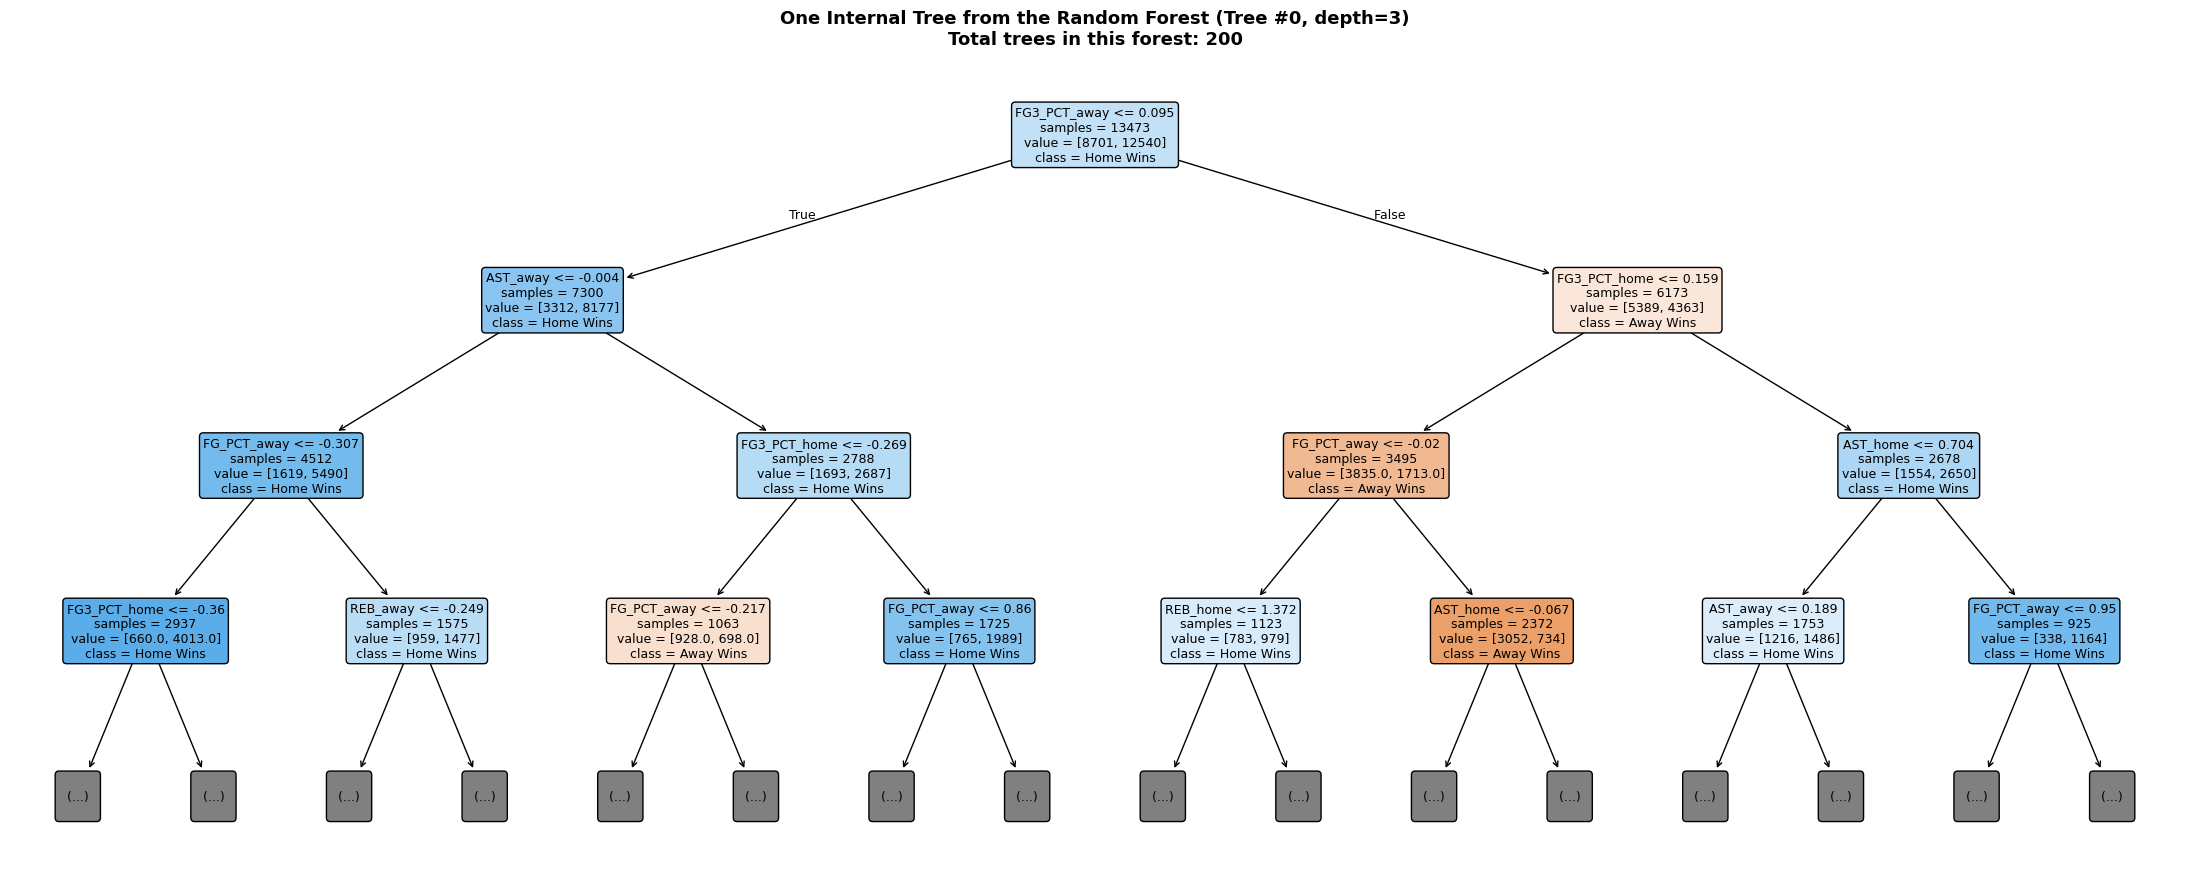

This tree uses feature: FG3_PCT_away as its root split
Total nodes in this single tree : 5149
Max depth of this single tree   : 23


In [16]:
from sklearn.tree import plot_tree

# Extract tree #0 from inside the trained Random Forest
single_tree = best_rf.estimators_[0]

plt.figure(figsize=(22, 9))
plot_tree(
    single_tree,
    feature_names=features,
    class_names=['Away Wins', 'Home Wins'],
    filled=True,
    rounded=True,
    max_depth=3,        # limit to 3 levels so it stays readable
    fontsize=9,
    impurity=False
)
plt.title(
    'One Internal Tree from the Random Forest (Tree #0, depth=3)\n'
    f'Total trees in this forest: {best_rf.n_estimators}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('rf_internal_tree.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'This tree uses feature: {features[single_tree.tree_.feature[0]]} as its root split')
print(f'Total nodes in this single tree : {single_tree.tree_.node_count}')
print(f'Max depth of this single tree   : {single_tree.get_depth()}')

In [17]:
# Cross-validation
cv_scores = cross_val_score(best_rf, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f'Cross-Validation Accuracy (5-fold): {cv_scores.mean()*100:.2f}%  -  {cv_scores.std()*100:.2f}%')

Cross-Validation Accuracy (5-fold): 83.86%  -  0.41%


## 7. Conclusions and Final Insights

| Metric | Score |
|--------|-------|
| Accuracy | 84.73% |
| Precision | 85.50% |
| Recall | 89.42% |
| F1-Score | 87.42% |
| ROC-AUC | 0.9231 |

**Key Observations:**
- Random Forest is an ensemble method that builds multiple decision trees and aggregates their predictions.
- It handles feature interactions and non-linear relationships well.
- Feature importance analysis reveals which statistics most influence game outcomes.
- Hyperparameter tuning with GridSearchCV improved generalization.


## Appendix A: Live Prediction Demo Interface
Use this section to demonstrate the model's prediction on a single game scenario.

In [18]:
import numpy as np
import pandas as pd

# 1. Select a random game from the test set for demonstration
random_idx = np.random.randint(0, len(X_test))
sample_game = X_test.iloc[random_idx]
actual_result = y_test.iloc[random_idx]

print('--- Game Scenario Features ---')
print(sample_game)
print('-' * 30)

# 2. Transform the sample for prediction
# Note: scaler.transform expects a 2D array-like input
sample_scaled = scaler.transform([sample_game.values])

# 3. Make prediction
# Automatically find the available model variable
model = None
for var_name in ['best_rf', 'best_svm', 'knn_best', 'best_knn', 'rf_model', 'svm_model', 'knn_model']:
    if var_name in globals():
        model = globals()[var_name]
        break

if model is None:
    print("Error: No trained model found in global scope.")
else:
    prediction = model.predict(sample_scaled)[0]
    proba = model.predict_proba(sample_scaled)[0]

    # 4. Display Results
    print(f'\n[VIVA DEMO RESULTS]')
    if prediction == 1:
        print('>>> PREDICTION: HOME TEAM WINS! 🏠')
        print(f'Confidence Score: {proba[1]*100:.2f}%')
    else:
        print('>>> PREDICTION: AWAY TEAM WINS! ✈️')
        print(f'Confidence Score: {proba[0]*100:.2f}%')

    result_text = "Home Win" if actual_result == 1 else "Away Win"
    status = "✅ CORRECT" if prediction == actual_result else "❌ INCORRECT"
    print(f'Actual Result: {result_text} ({status})')

--- Game Scenario Features ---
FG_PCT_home      0.567
FT_PCT_home      0.763
FG3_PCT_home     0.563
AST_home        15.000
REB_home        42.000
FG_PCT_away      0.438
FT_PCT_away      0.727
FG3_PCT_away     0.292
AST_away        20.000
REB_away        29.000
Name: 24167, dtype: float64
------------------------------

[VIVA DEMO RESULTS]
>>> PREDICTION: HOME TEAM WINS! 🏠
Confidence Score: 97.00%
Actual Result: Home Win (✅ CORRECT)
